In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import phys_grad, compute_core_mean


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
# dic_vert = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/dic_vert_doppio_50m_vert_checked.pkl')


In [3]:
# Field Data
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid = lon_rho.shape[1] // 2
i_mid = lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
prop_dist = (
    df_eddies
    .groupby('Eddy')[['xc', 'yc']]
    .apply(lambda g: np.nansum(np.hypot(g.xc.diff(), g.yc.diff())))
)
df_eddies['PropDist'] = df_eddies['Eddy'].map(prop_dist)
eddy = df_eddies[df_eddies.PropDist.max() == df_eddies.PropDist].Eddy.unique()[0]
eddy


np.int64(983)

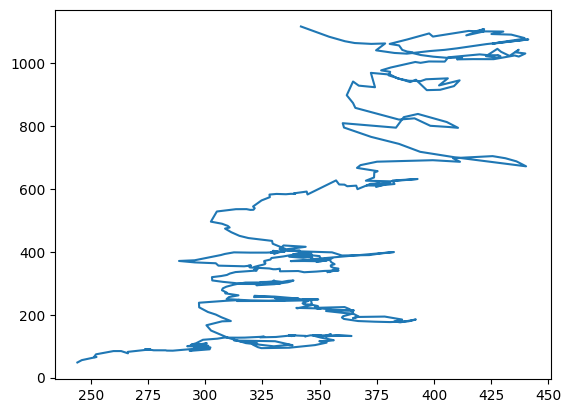

In [5]:
df = df_eddies[df_eddies.Eddy==eddy].copy()
plt.plot(df.xc, df.yc)


In [28]:
def plot_best_fit(
    x, y,
    ax=None,
    xlabel='',
    scatter_kwargs=None,
    line_kwargs=None,
    text_loc=(0.03, 0.97)
):

    if ax is None:
        ax = plt.gca()

    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    scatter_kwargs = {} if scatter_kwargs is None else scatter_kwargs
    line_kwargs = {'color': 'k', 'lw': 2} | (line_kwargs or {})

    ax.scatter(x, y, marker='.', alpha=0.4, **scatter_kwargs)

    m, b = np.polyfit(x, y, 1)

    xx = np.array([x.min(), x.max()])
    ax.plot(xx, m*xx + b, **line_kwargs)

    yhat = m*x + b
    r2 = 1 - np.sum((y-yhat)**2) / np.sum((y-y.mean())**2)

    ax.text(
        *text_loc,
        f'$m$={m:.2g}\n$R^2$={r2:.2f}',
        transform=ax.transAxes,
        va='top'
    )

    ax.set_xlabel(xlabel)

    return m, b, r2
    

Text(0, 0.5, 'Tilt distance (km)')

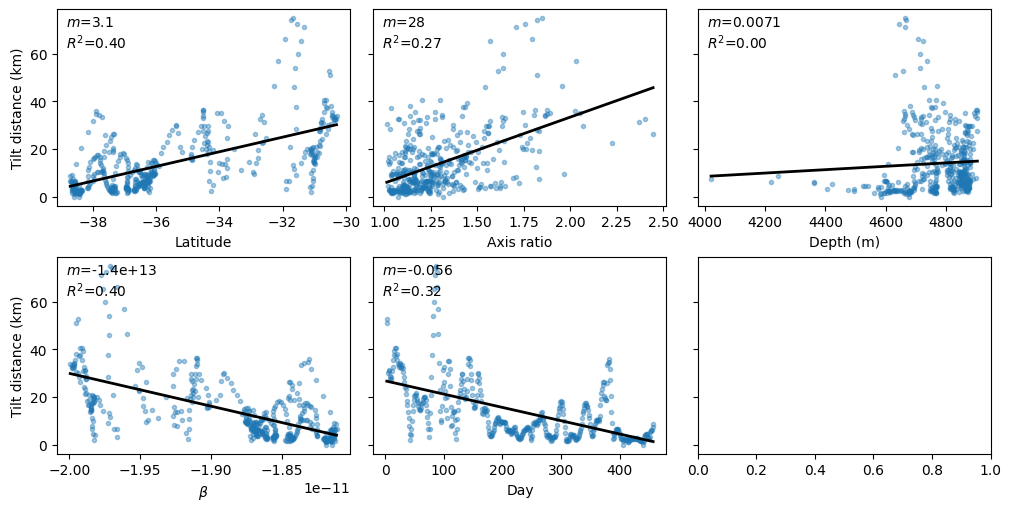

In [39]:
fig, axs = plt.subplots(
    2, 3,
    figsize=(10, 5),
    sharey=True,
    constrained_layout=True
)

axs = axs.ravel()

plot_best_fit(df.lat, df.TiltDis, ax=axs[0], xlabel='Latitude')

plot_best_fit(df.AR, df.TiltDis, ax=axs[1], xlabel='Axis ratio')

df['h'] = h[df.ic, df.jc]
plot_best_fit(df.h, df.TiltDis, ax=axs[2], xlabel='Depth (m)')

dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)
df['beta'] = df_dN[df.ic, df.jc]
plot_best_fit(df.beta, df.TiltDis, ax=axs[3], xlabel=r'$\beta$')

plot_best_fit(df.Day-df.Day.iloc[0], df.TiltDis, ax=axs[4], xlabel='Day')

axs[0].set_ylabel('Tilt distance (km)')
axs[3].set_ylabel('Tilt distance (km)')


(np.float64(0.0),
 np.float64(988.1356688684336),
 np.float64(0.0),
 np.float64(1561.702894718129))

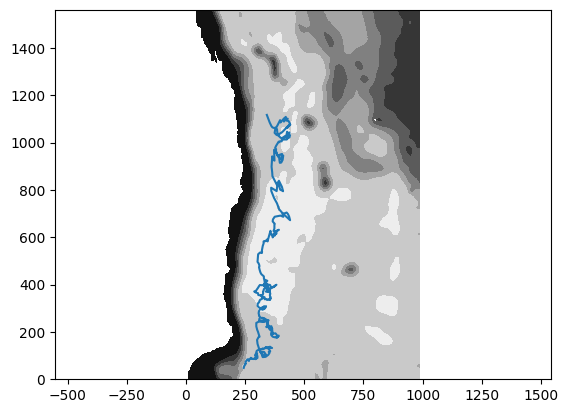

In [45]:
plt.contourf(X_grid, Y_grid, np.where(mask_rho, h, np.nan), cmap='grey')
plt.plot(df.xc, df.yc)
plt.axis('equal')


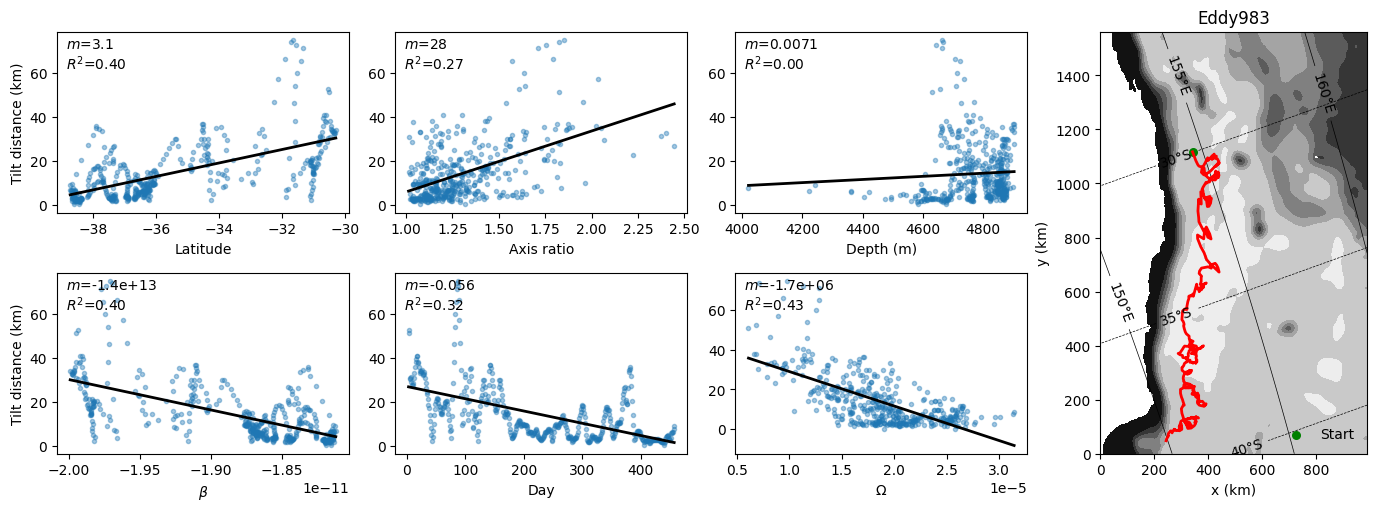

In [61]:
fig = plt.figure(figsize=(14, 5), constrained_layout=True)

gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1.15])

axs = np.array([
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
])

ax_map = fig.add_subplot(gs[:, 3])

plot_best_fit(df.lat, df.TiltDis, ax=axs[0], xlabel='Latitude')
plot_best_fit(df.AR, df.TiltDis, ax=axs[1], xlabel='Axis ratio')

df['h'] = h[df.ic, df.jc]
plot_best_fit(df.h, df.TiltDis, ax=axs[2], xlabel='Depth (m)')
# plot_best_fit(df.w, df.TiltDis, ax=axs[2], xlabel=r'$\omega$')

dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)

df['beta'] = df_dN[df.ic, df.jc]
plot_best_fit(df.beta, df.TiltDis, ax=axs[3], xlabel=r'$\beta$')

plot_best_fit(df.Day - df.Day.iloc[0], df.TiltDis, ax=axs[4], xlabel='Day')

plot_best_fit(df.Omega, df.TiltDis, ax=axs[5], xlabel=r'$\Omega$')

axs[0].set_ylabel('Tilt distance (km)')
axs[3].set_ylabel('Tilt distance (km)')

ax_map.contourf(
    X_grid,
    Y_grid,
    np.where(mask_rho, h, np.nan),
    cmap='grey'
)
c1 = ax_map.contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
ax_map.clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
c2 = ax_map.contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
ax_map.clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')
    
ax_map.plot(df.xc, df.yc, color='r', lw=2)
ax_map.scatter(df.xc.iloc[0], df.yc.iloc[0], color='g', s=30, label='Start')
# ax_map.scatter(df.xc.iloc[-1], df.yc.iloc[-1], color='r', s=30, label='End')


ax_map.set_aspect('equal')
ax_map.set_xlabel('x (km)')
ax_map.set_ylabel('y (km)')
ax_map.set_title(f'Eddy{eddy}')
ax_map.legend(frameon=False, loc='lower right')



In [58]:
df.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R', 'Age', 'Date',
       'fname', 'TiltDis', 'TiltDir', 'PropDist', 'h', 'beta'],
      dtype='object')